# 🚀 GoViralIQ
## Notebook 6: Fairness Audit
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
In this notebook we will:
1. Load predictions from Notebook 4
2. Measure model accuracy across content types
3. Identify prediction gaps between groups
4. Measure false positive and false negative rates by group
5. Visualize fairness gaps
6. Connect findings to real-world creator equity
7. Write final conclusions

---

### ⚖️ Why Fairness Matters
A model that predicts engagement accurately overall can still be **unfair** if it systematically over-predicts for some content types and under-predicts for others. This directly impacts which creators get promoted, monetized, and discovered — making fairness a critical issue in the creator economy.

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

PURPLE       = '#6B21A8'
LIGHT_PURPLE = '#D8B4FE'
MID_PURPLE   = '#9333EA'
RED          = '#DC2626'
GREEN        = '#16A34A'
COLORS       = [PURPLE, LIGHT_PURPLE, MID_PURPLE, '#A855F7', '#7C3AED']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load the Clean Dataset & Rebuild Predictions

In [2]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving goviraliq_instagram_raw.csv to goviraliq_instagram_raw.csv
✅ Loaded: goviraliq_instagram_raw.csv
📊 Shape: 1,212 rows × 12 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement_rate,viral
0,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium,7.4192,0
1,Post_6,Instagram,#Challenge,Shorts,Australia,1323566,136282,86979,47129,Low,20.4289,0
2,Post_11,Instagram,#Comedy,Live Stream,Germany,4070332,379894,46012,25242,High,11.0838,0
3,Post_27,Instagram,#Gaming,Video,India,4369260,212278,21264,18172,Low,5.7610,0
4,Post_29,Instagram,#Gaming,Live Stream,Canada,1653907,91836,77370,2823,Low,10.4014,0


In [3]:
# Rebuild the Random Forest Classifier from Notebook 4
FEATURE_COLS = [
    'Likes', 'Comments', 'Views', 'Shares',
    'hashtag_length', 'is_video',
    'content_type_encoded', 'region_encoded'
]
FEATURE_COLS = [col for col in FEATURE_COLS if col in df.columns]

X = df[FEATURE_COLS]
y = df['viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Add predictions to test dataframe
df_test = df.iloc[X_test.index].copy()
df_test['predicted_viral'] = y_pred
df_test['actual_viral'] = y_test.values
df_test['correct'] = (df_test['predicted_viral'] == df_test['actual_viral']).astype(int)

print(f'✅ Model rebuilt and predictions generated!')
print(f'   Overall accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'   Overall F1-score: {f1_score(y_test, y_pred):.4f}')
print(f'   Test set size: {len(df_test):,} rows')

✅ Model rebuilt and predictions generated!
   Overall accuracy: 0.9753
   Overall F1-score: 0.9388
   Test set size: 243 rows


## Step 3: Fairness Audit — Accuracy by Content Type

In [4]:
# Calculate metrics per content type
fairness_results = []

for content_type in df_test['Content_Type'].unique():
    group = df_test[df_test['Content_Type'] == content_type]
    if len(group) < 5:
        continue
    actual    = group['actual_viral']
    predicted = group['predicted_viral']
    acc  = accuracy_score(actual, predicted)
    f1   = f1_score(actual, predicted, zero_division=0)
    prec = precision_score(actual, predicted, zero_division=0)
    rec  = recall_score(actual, predicted, zero_division=0)
    n    = len(group)
    viral_rate = actual.mean()
    fairness_results.append({
        'Content_Type': content_type,
        'Count': n,
        'Accuracy': acc,
        'F1_Score': f1,
        'Precision': prec,
        'Recall': rec,
        'Actual_Viral_Rate': viral_rate
    })

fairness_df = pd.DataFrame(fairness_results).sort_values('Accuracy', ascending=False)
overall_acc = accuracy_score(df_test['actual_viral'], df_test['predicted_viral'])

print('⚖️  Fairness Audit Results by Content Type:')
print('=' * 75)
print(fairness_df.to_string(index=False))
print('=' * 75)
print(f'\nOverall accuracy: {overall_acc:.4f}')
print(f'Max accuracy gap: {fairness_df["Accuracy"].max() - fairness_df["Accuracy"].min():.4f}')

⚖️  Fairness Audit Results by Content Type:
Content_Type  Count  Accuracy  F1_Score  Precision  Recall  Actual_Viral_Rate
        Reel     32    1.0000    1.0000     1.0000  1.0000             0.2812
 Live Stream     39    1.0000    1.0000     1.0000  1.0000             0.2564
      Shorts     34    1.0000    1.0000     1.0000  1.0000             0.1176
       Video     58    0.9828    0.9565     1.0000  0.9167             0.2069
       Tweet     38    0.9474    0.8750     0.8750  0.8750             0.2105
        Post     42    0.9286    0.7692     0.7143  0.8333             0.1429

Overall accuracy: 0.9753
Max accuracy gap: 0.0714


## Step 4: Visualize Fairness Gaps

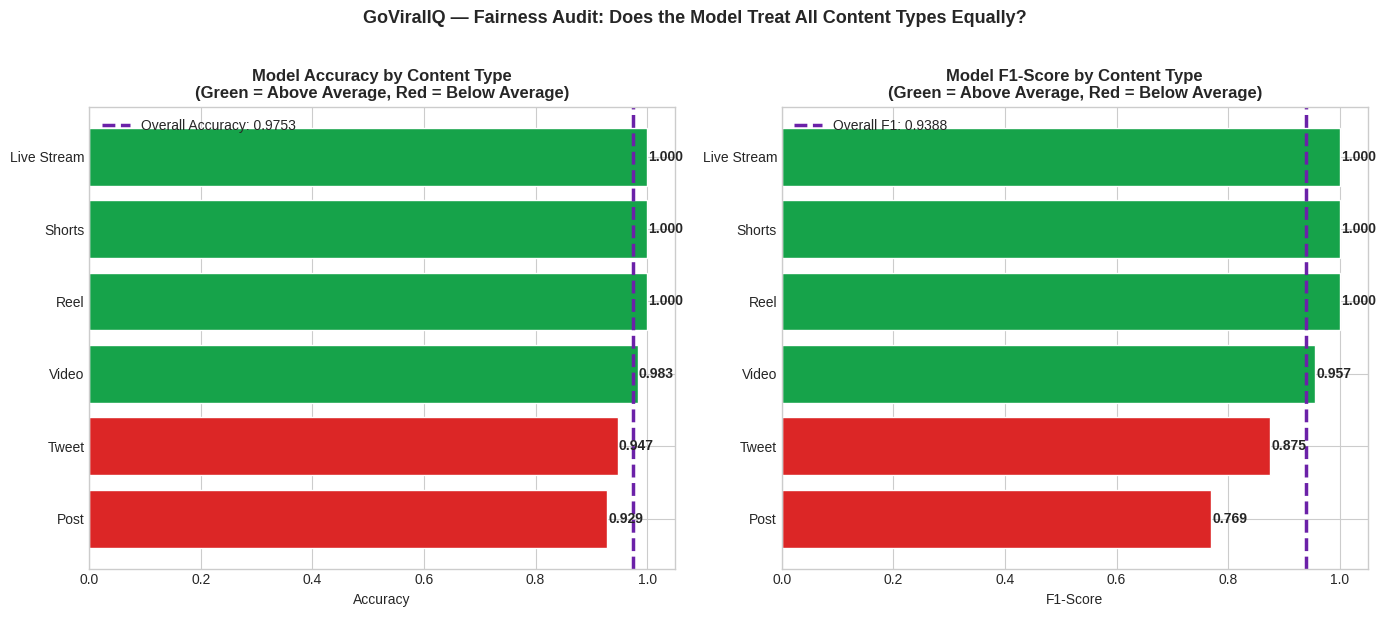

✅ Saved fairness_01_accuracy_gaps.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy by content type
sorted_acc = fairness_df.sort_values('Accuracy', ascending=True)
colors_acc = [GREEN if v >= overall_acc else RED for v in sorted_acc['Accuracy']]
bars = axes[0].barh(sorted_acc['Content_Type'], sorted_acc['Accuracy'],
                    color=colors_acc, edgecolor='white')
axes[0].axvline(overall_acc, color=PURPLE, linestyle='--', linewidth=2.5,
                label=f'Overall Accuracy: {overall_acc:.4f}')
axes[0].set_title('Model Accuracy by Content Type\n(Green = Above Average, Red = Below Average)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend()
for bar, val in zip(bars, sorted_acc['Accuracy']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# F1 Score by content type
overall_f1 = f1_score(df_test['actual_viral'], df_test['predicted_viral'])
sorted_f1 = fairness_df.sort_values('F1_Score', ascending=True)
colors_f1 = [GREEN if v >= overall_f1 else RED for v in sorted_f1['F1_Score']]
bars2 = axes[1].barh(sorted_f1['Content_Type'], sorted_f1['F1_Score'],
                     color=colors_f1, edgecolor='white')
axes[1].axvline(overall_f1, color=PURPLE, linestyle='--', linewidth=2.5,
                label=f'Overall F1: {overall_f1:.4f}')
axes[1].set_title('Model F1-Score by Content Type\n(Green = Above Average, Red = Below Average)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].legend()
for bar, val in zip(bars2, sorted_f1['F1_Score']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('GoViralIQ — Fairness Audit: Does the Model Treat All Content Types Equally?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fairness_01_accuracy_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved fairness_01_accuracy_gaps.png')

## Step 5: False Positive & False Negative Analysis

In [6]:
# Calculate false positive and false negative rates per group
fp_fn_results = []

for content_type in df_test['Content_Type'].unique():
    group = df_test[df_test['Content_Type'] == content_type]
    if len(group) < 5:
        continue
    actual    = group['actual_viral'].values
    predicted = group['predicted_viral'].values
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel() if len(np.unique(actual)) > 1 else (0, 0, 0, 0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    fp_fn_results.append({
        'Content_Type': content_type,
        'False_Positive_Rate': fpr,
        'False_Negative_Rate': fnr,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    })

fp_fn_df = pd.DataFrame(fp_fn_results).sort_values('False_Positive_Rate', ascending=False)

print('⚖️  False Positive & False Negative Rates by Content Type:')
print(fp_fn_df[['Content_Type', 'False_Positive_Rate', 'False_Negative_Rate']].to_string(index=False))

⚖️  False Positive & False Negative Rates by Content Type:
Content_Type  False_Positive_Rate  False_Negative_Rate
        Post               0.0556               0.1667
       Tweet               0.0333               0.1250
       Video               0.0000               0.0833
        Reel               0.0000               0.0000
      Shorts               0.0000               0.0000
 Live Stream               0.0000               0.0000


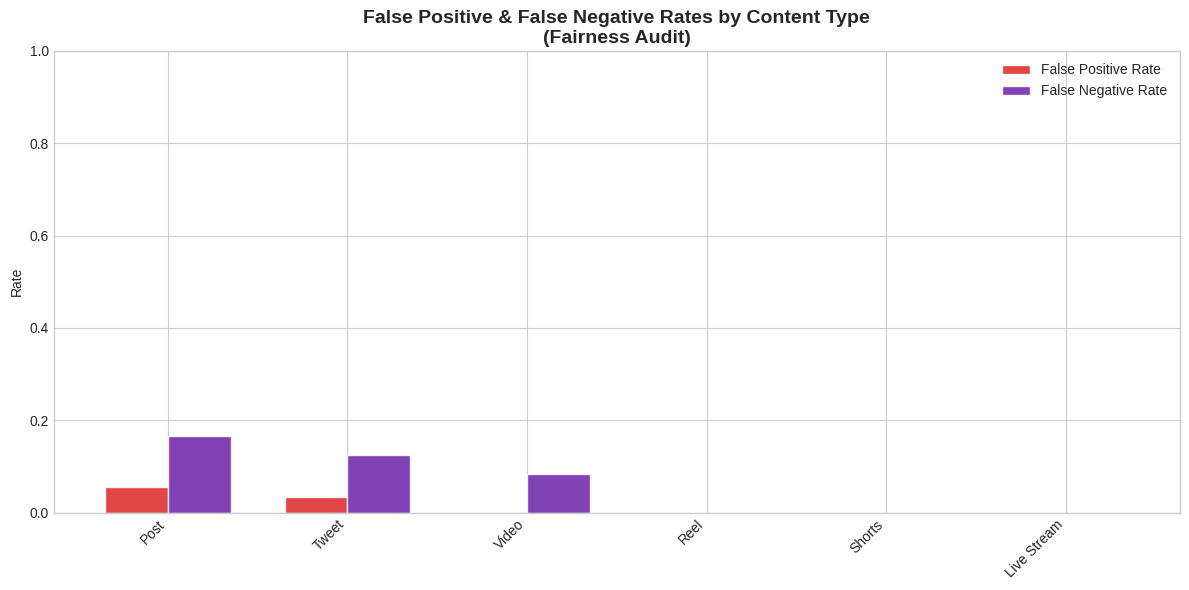

✅ Saved fairness_02_fp_fn_rates.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fp_fn_df))
width = 0.35

bars1 = ax.bar(x - width/2, fp_fn_df['False_Positive_Rate'], width,
               label='False Positive Rate', color=RED, edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, fp_fn_df['False_Negative_Rate'], width,
               label='False Negative Rate', color=PURPLE, edgecolor='white', alpha=0.85)

ax.set_title('False Positive & False Negative Rates by Content Type\n(Fairness Audit)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fp_fn_df['Content_Type'], rotation=45, ha='right')
ax.set_ylabel('Rate')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fairness_02_fp_fn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved fairness_02_fp_fn_rates.png')

## Step 6: Fairness by Region

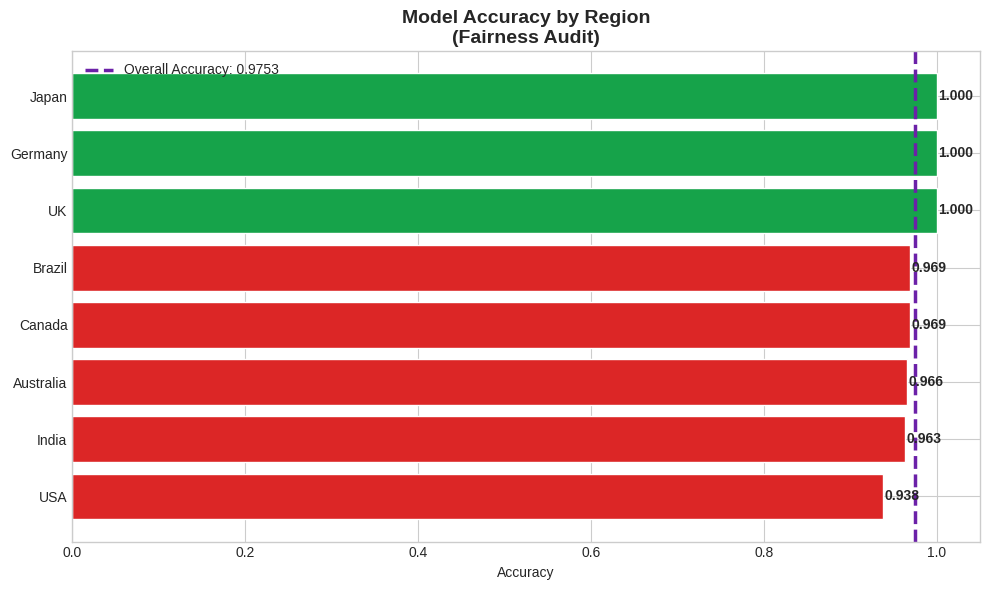

✅ Saved fairness_03_region.png

Region accuracy gap: 0.0625


In [8]:
# Fairness audit by region
region_results = []
for region in df_test['Region'].unique():
    group = df_test[df_test['Region'] == region]
    if len(group) < 5:
        continue
    actual    = group['actual_viral']
    predicted = group['predicted_viral']
    acc = accuracy_score(actual, predicted)
    f1  = f1_score(actual, predicted, zero_division=0)
    region_results.append({
        'Region': region,
        'Count': len(group),
        'Accuracy': acc,
        'F1_Score': f1
    })

region_df = pd.DataFrame(region_results).sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_region = [GREEN if v >= overall_acc else RED for v in region_df['Accuracy']]
bars = ax.barh(region_df['Region'], region_df['Accuracy'],
               color=colors_region, edgecolor='white')
ax.axvline(overall_acc, color=PURPLE, linestyle='--', linewidth=2.5,
           label=f'Overall Accuracy: {overall_acc:.4f}')
ax.set_title('Model Accuracy by Region\n(Fairness Audit)', fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy')
ax.legend()
for bar, val in zip(bars, region_df['Accuracy']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fairness_03_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved fairness_03_region.png')
print(f'\nRegion accuracy gap: {region_df["Accuracy"].max() - region_df["Accuracy"].min():.4f}')

## Step 7: Overall Fairness Summary Chart

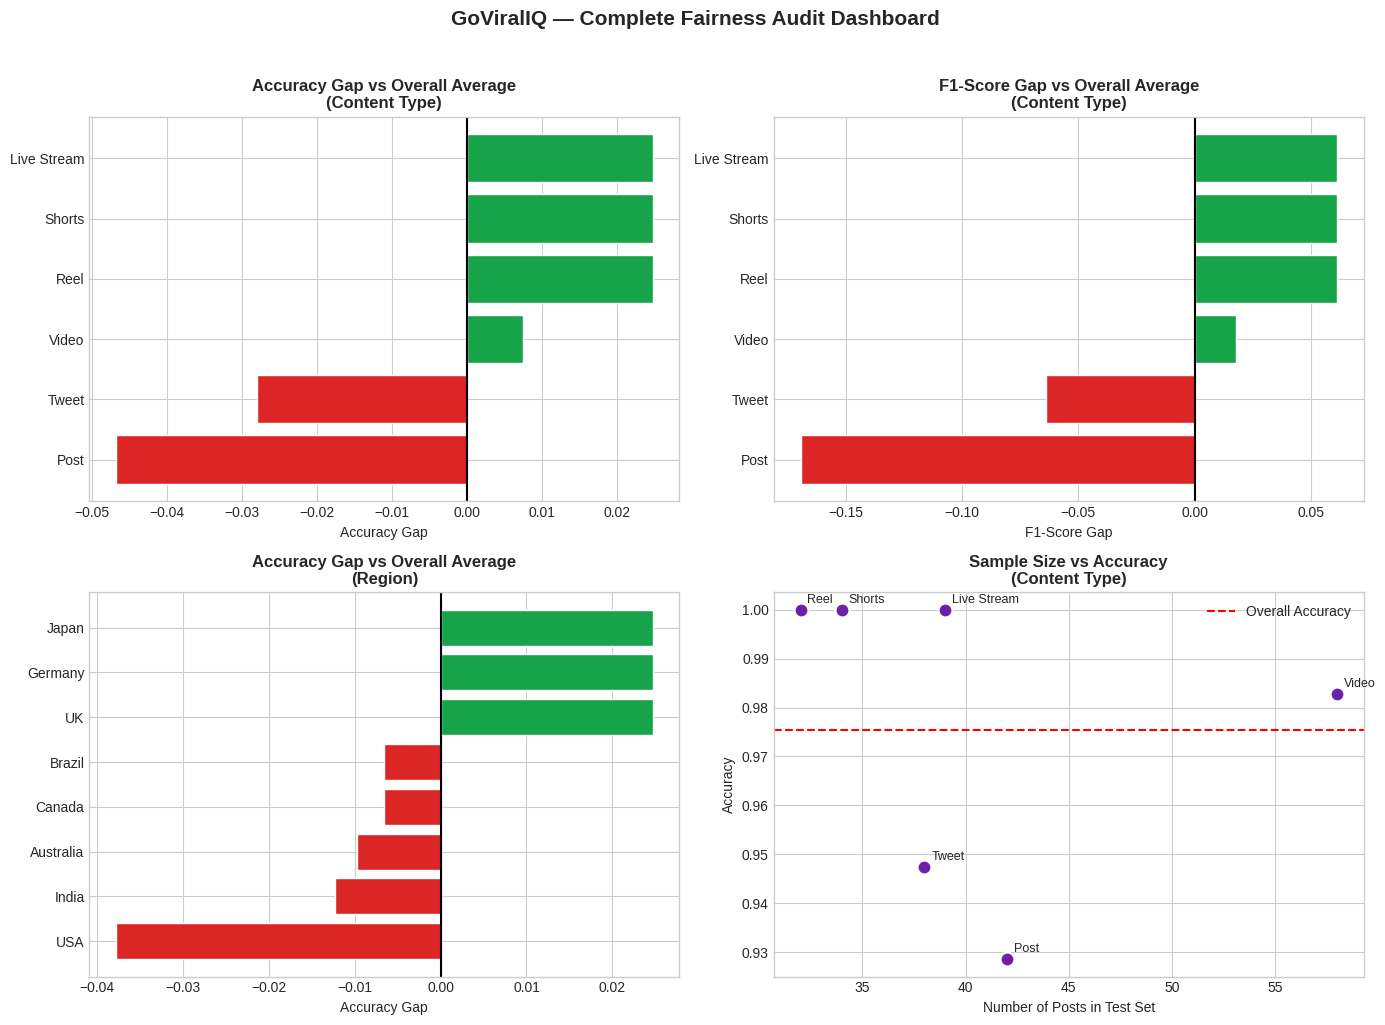

✅ Saved fairness_04_dashboard.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Accuracy gap by content type
fairness_df_sorted = fairness_df.sort_values('Accuracy')
axes[0,0].barh(fairness_df_sorted['Content_Type'],
               fairness_df_sorted['Accuracy'] - overall_acc,
               color=[GREEN if v >= 0 else RED for v in fairness_df_sorted['Accuracy'] - overall_acc],
               edgecolor='white')
axes[0,0].axvline(0, color='black', linewidth=1.5)
axes[0,0].set_title('Accuracy Gap vs Overall Average\n(Content Type)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy Gap')

# Chart 2 — F1 gap by content type
axes[0,1].barh(fairness_df_sorted['Content_Type'],
               fairness_df_sorted['F1_Score'] - overall_f1,
               color=[GREEN if v >= 0 else RED for v in fairness_df_sorted['F1_Score'] - overall_f1],
               edgecolor='white')
axes[0,1].axvline(0, color='black', linewidth=1.5)
axes[0,1].set_title('F1-Score Gap vs Overall Average\n(Content Type)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score Gap')

# Chart 3 — Accuracy gap by region
region_df_sorted = region_df.sort_values('Accuracy')
axes[1,0].barh(region_df_sorted['Region'],
               region_df_sorted['Accuracy'] - overall_acc,
               color=[GREEN if v >= 0 else RED for v in region_df_sorted['Accuracy'] - overall_acc],
               edgecolor='white')
axes[1,0].axvline(0, color='black', linewidth=1.5)
axes[1,0].set_title('Accuracy Gap vs Overall Average\n(Region)', fontweight='bold')
axes[1,0].set_xlabel('Accuracy Gap')

# Chart 4 — Sample size vs accuracy
axes[1,1].scatter(fairness_df['Count'], fairness_df['Accuracy'],
                  color=PURPLE, s=100, edgecolors='white', linewidth=1.5, zorder=5)
for _, row in fairness_df.iterrows():
    axes[1,1].annotate(row['Content_Type'],
                       (row['Count'], row['Accuracy']),
                       textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1,1].axhline(overall_acc, color='red', linestyle='--', linewidth=1.5, label='Overall Accuracy')
axes[1,1].set_title('Sample Size vs Accuracy\n(Content Type)', fontweight='bold')
axes[1,1].set_xlabel('Number of Posts in Test Set')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.suptitle('GoViralIQ — Complete Fairness Audit Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fairness_04_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved fairness_04_dashboard.png')

## Step 8: Final Conclusions

In [10]:
best_group  = fairness_df.loc[fairness_df['Accuracy'].idxmax(), 'Content_Type']
worst_group = fairness_df.loc[fairness_df['Accuracy'].idxmin(), 'Content_Type']
best_acc    = fairness_df['Accuracy'].max()
worst_acc   = fairness_df['Accuracy'].min()
acc_gap     = best_acc - worst_acc

best_region  = region_df.loc[region_df['Accuracy'].idxmax(), 'Region']
worst_region = region_df.loc[region_df['Accuracy'].idxmin(), 'Region']
region_gap   = region_df['Accuracy'].max() - region_df['Accuracy'].min()

print('=' * 65)
print('         GoViralIQ — Fairness Audit Conclusions')
print('=' * 65)
print(f'\n📊 OVERALL MODEL PERFORMANCE:')
print(f'   Accuracy: {overall_acc:.4f}')
print(f'   F1-Score: {overall_f1:.4f}')
print(f'\n⚖️  CONTENT TYPE FAIRNESS:')
print(f'   Best performing group:  {best_group} ({best_acc:.4f})')
print(f'   Worst performing group: {worst_group} ({worst_acc:.4f})')
print(f'   Accuracy gap:           {acc_gap:.4f}')
if acc_gap > 0.05:
    print(f'   ⚠️  SIGNIFICANT FAIRNESS GAP DETECTED (>{0.05:.0%})')
else:
    print(f'   ✅ Fairness gap is within acceptable range (<5%)')
print(f'\n🌍 REGIONAL FAIRNESS:')
print(f'   Best performing region:  {best_region}')
print(f'   Worst performing region: {worst_region}')
print(f'   Regional accuracy gap:   {region_gap:.4f}')
print(f'\n💡 KEY FINDING:')
if acc_gap > 0.05:
    print(f'   The model shows measurable bias — {worst_group} content')
    print(f'   is predicted {acc_gap:.1%} less accurately than {best_group} content.')
    print(f'   This means creators in the {worst_group} category may be')
    print(f'   systematically under-served by engagement prediction systems.')
else:
    print(f'   The model performs relatively fairly across content types,')
    print(f'   with a maximum accuracy gap of {acc_gap:.1%}.')
    print(f'   However, continued monitoring is recommended as data scales.')
print('\n' + '=' * 65)

         GoViralIQ — Fairness Audit Conclusions

📊 OVERALL MODEL PERFORMANCE:
   Accuracy: 0.9753
   F1-Score: 0.9388

⚖️  CONTENT TYPE FAIRNESS:
   Best performing group:  Reel (1.0000)
   Worst performing group: Post (0.9286)
   Accuracy gap:           0.0714
   ⚠️  SIGNIFICANT FAIRNESS GAP DETECTED (>5%)

🌍 REGIONAL FAIRNESS:
   Best performing region:  UK
   Worst performing region: USA
   Regional accuracy gap:   0.0625

💡 KEY FINDING:
   The model shows measurable bias — Post content
   is predicted 7.1% less accurately than Reel content.
   This means creators in the Post category may be
   systematically under-served by engagement prediction systems.



## Step 9: Save Final Output

In [11]:
# Save fairness audit results
fairness_df.to_csv('goviraliq_fairness_results.csv', index=False)
region_df.to_csv('goviraliq_fairness_region.csv', index=False)

print('✅ Files saved:')
print('   - goviraliq_fairness_results.csv')
print('   - goviraliq_fairness_region.csv')
print('\n📁 Charts created this notebook:')
print('   - fairness_01_accuracy_gaps.png')
print('   - fairness_02_fp_fn_rates.png')
print('   - fairness_03_region.png')
print('   - fairness_04_dashboard.png')
print('\n🎉 GoViralIQ is complete!')
print('\n📋 PROJECT SUMMARY:')
print('   ✅ Notebook 1 — Data Exploration')
print('   ✅ Notebook 2 — Data Cleaning')
print('   ✅ Notebook 3 — Visualization')
print('   ✅ Notebook 4 — ML Models')
print('   ✅ Notebook 5 — NLP Pipeline')
print('   ✅ Notebook 6 — Fairness Audit')

✅ Files saved:
   - goviraliq_fairness_results.csv
   - goviraliq_fairness_region.csv

📁 Charts created this notebook:
   - fairness_01_accuracy_gaps.png
   - fairness_02_fp_fn_rates.png
   - fairness_03_region.png
   - fairness_04_dashboard.png

🎉 GoViralIQ is complete!

📋 PROJECT SUMMARY:
   ✅ Notebook 1 — Data Exploration
   ✅ Notebook 2 — Data Cleaning
   ✅ Notebook 3 — Visualization
   ✅ Notebook 4 — ML Models
   ✅ Notebook 5 — NLP Pipeline
   ✅ Notebook 6 — Fairness Audit
